### <b>Análisis y predicción de datos: Football Salaries FIFA 22</b>
#### <b><i>Fase III: Análisis Multivariante</i></b>
Hasta ahora hemos mirado las variables de a una o de a dos: su distribución, su correlación individual con el sueldo, las diferencias entre grupos. Pero un jugador de fútbol no es una suma de atributos independientes: quien regatea bien casi siempre controla bien el balón, y quien ataja penales suele también leer bien los centros. Las habilidades vienen "en paquetes". El análisis multivariante busca precisamente eso: entender cómo se relacionan las variables *entre sí*, no solo con el target.

Los objetivos de esta fase son:
1. Construir la matriz de correlación completa y detectar redundancias entre variables técnicas.
2. Aplicar reducción dimensional (PCA) para resumir la información sin perder lo esencial.
3. Identificar los grandes grupos de variables correlacionadas (ataque, defensa, portería, físico).
4. Traducir estos hallazgos en criterios concretos para la selección de features del modelado.

#### <b><i>1. Matriz de correlación y detección de redundancias</i></b>
Empezamos por la foto completa: la matriz de correlación de todas las variables numéricas entre sí. A diferencia del EDA —donde solo mirábamos la correlación de cada variable *con el sueldo*— aquí nos interesa el cruce de todas contra todas. Buscamos **redundancias**: pares de variables tan correlacionadas que, en la práctica, dicen casi lo mismo. Detectarlas es importante porque la información repetida no aporta al modelo y, en modelos lineales, incluso lo perjudica (multicolinealidad).

Variables numéricas predictoras: 27


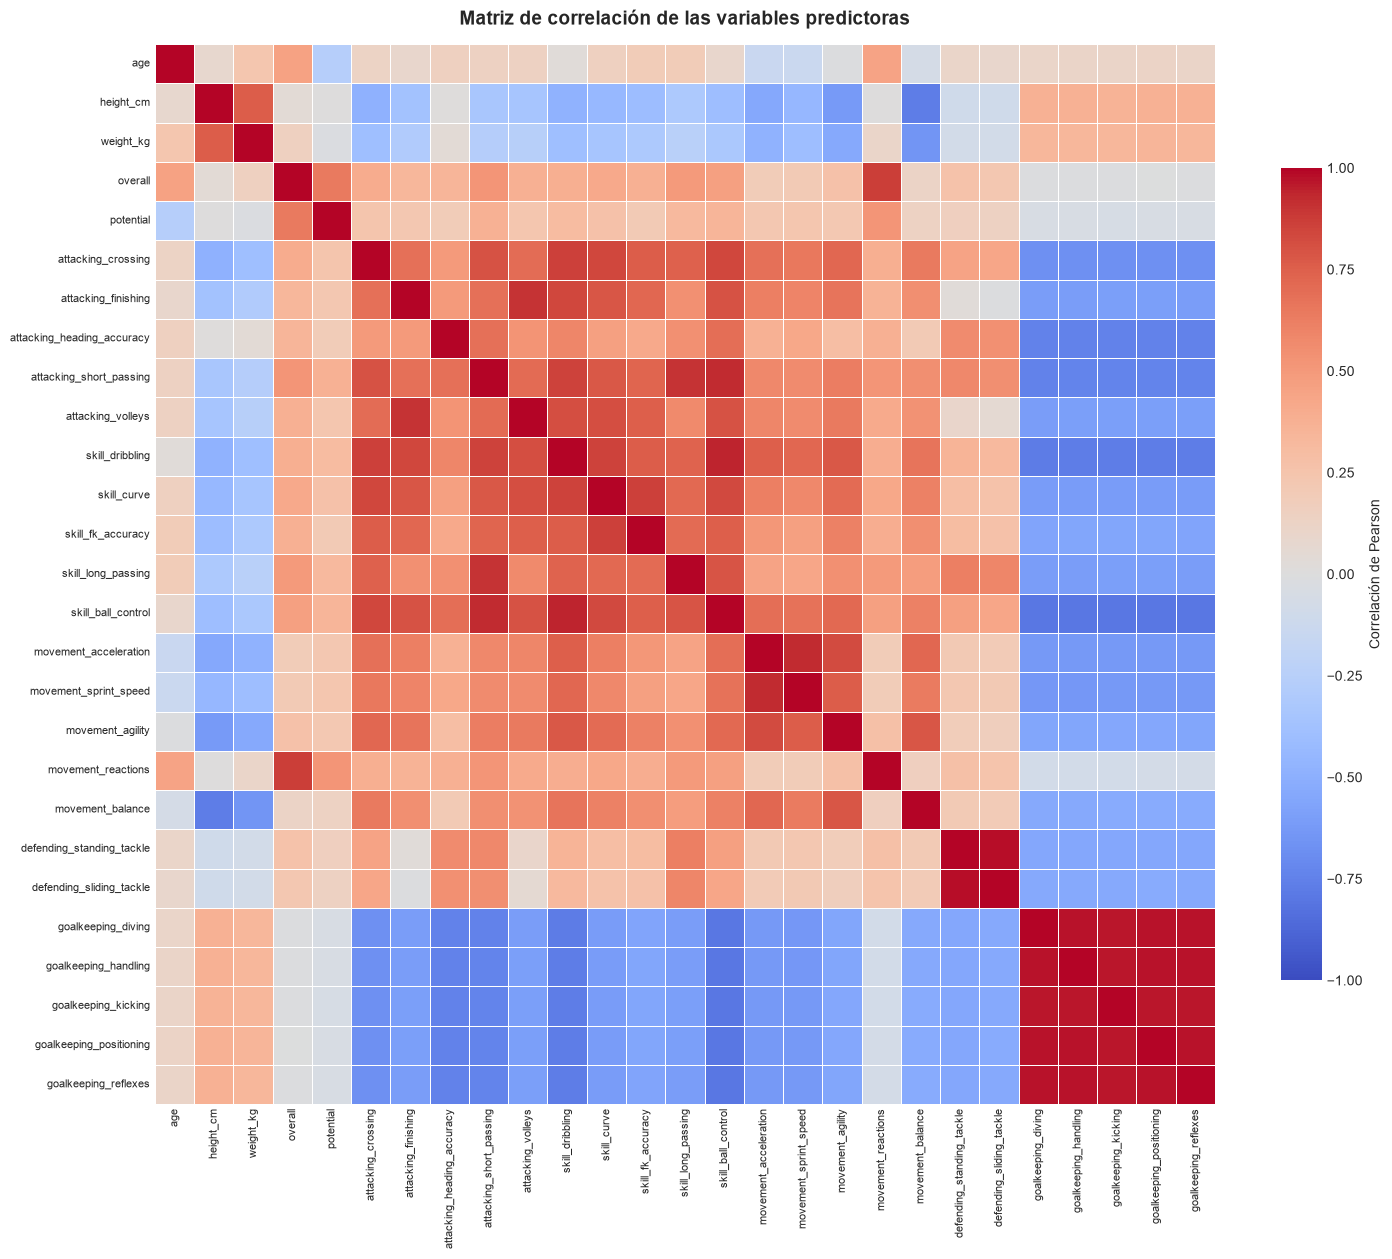

In [1]:
# Librerías
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sbs

# Cargamos el dataset
path = os.path.join(os.getcwd(), "..", "data", "raw", "dataset.csv")
df = pd.read_csv(path)

# Nos quedamos con las variables numéricas; separamos el target para el análisis entre predictoras
num = df.select_dtypes("number")
predictoras = num.drop(columns=["wage_eur"])
print("Variables numéricas predictoras:", predictoras.shape[1])

# Matriz de correlación completa
corr = predictoras.corr()

# Heatmap
plt.style.use("seaborn-v0_8-whitegrid")
fig, ax = plt.subplots(figsize=(15, 13))
sbs.heatmap(corr, cmap="coolwarm", center=0, vmin=-1, vmax=1,
            square=True, linewidths=0.4, linecolor="white",
            cbar_kws={"shrink": 0.7, "label": "Correlación de Pearson"}, ax=ax)
ax.set_title("Matriz de correlación de las variables predictoras", fontsize=14, fontweight="bold", pad=14)
ax.tick_params(labelsize=8)
plt.tight_layout()
plt.show()

In [2]:
# Detección automática de pares altamente redundantes (|correlación| >= 0.85)
umbral = 0.85
mascara = np.triu(np.ones(corr.shape, dtype=bool), k=1)  # solo triángulo superior, sin diagonal
pares = (
    corr.where(mascara)
    .stack()
    .reset_index()
    .rename(columns={"level_0": "Variable A", "level_1": "Variable B", 0: "Correlación"})
)
redundantes = pares[pares["Correlación"].abs() >= umbral].sort_values("Correlación", ascending=False)
print(f"Pares con |correlación| >= {umbral}: {len(redundantes)}")
redundantes.reset_index(drop=True).round(3)

Pares con |correlación| >= 0.85: 21


,Variable A,Variable B,Correlación
0,defending_standing_tackle,defending_sliding_tackle,0.977
1,goalkeeping_diving,goalkeeping_reflexes,0.974
2,goalkeeping_handling,goalkeeping_reflexes,0.972
3,goalkeeping_diving,goalkeeping_handling,0.972
4,goalkeeping_positioning,goalkeeping_reflexes,0.971
5,goalkeeping_diving,goalkeeping_positioning,0.971
6,goalkeeping_handling,goalkeeping_positioning,0.971
7,goalkeeping_kicking,goalkeeping_reflexes,0.969
8,goalkeeping_diving,goalkeeping_kicking,0.968
9,goalkeeping_handling,goalkeeping_kicking,0.968


<b>Explicación</b>: El mapa de calor no es un mar aleatorio de colores: se organiza en **bloques rojos** bien definidos a lo largo de la diagonal, y cada bloque cuenta una historia futbolística. Se distinguen a simple vista tres o cuatro cuadrantes muy correlacionados internamente:

- Un bloque de **atributos de portero** (`goalkeeping_*`) que forma el cuadrado rojo más intenso de todos.
- Un bloque de **habilidades técnicas de ataque/skill** (regate, control de balón, pases, centros, efecto).
- Un bloque **físico/de movimiento** (aceleración y velocidad de sprint van casi de la mano).
- Un bloque **defensivo** (entrada de pie y entrada deslizante, prácticamente idénticas).

La tabla de redundancias lo confirma con números: los cinco atributos de portero correlacionan entre sí por encima de **0.96** —son, a efectos prácticos, una sola dimensión "ser portero"—; las dos variables defensivas comparten un **0.98**; y regate y control de balón, un **0.94**. Estas no son coincidencias: reflejan que las habilidades futbolísticas se agrupan por rol y por tipo de gesto técnico.

#### <b><i>Conclusión</i></b>
La matriz de correlación revela una fuerte **estructura de bloques**: buena parte de las 27 variables predictoras no aportan información independiente, sino que se solapan dentro de grupos temáticos (portería, ataque/técnica, físico, defensa). El caso más extremo es el de los atributos de portero, tan correlacionados entre sí que podrían resumirse en un único indicador sin apenas pérdida. Esta redundancia es una oportunidad: sugiere que podemos **comprimir muchas columnas en unas pocas dimensiones representativas**, que es exactamente lo que abordaremos con el PCA en la siguiente sección.

#### <b><i>2. Reducción dimensional con PCA</i></b>
La matriz de correlación nos dijo que hay mucha información repetida. El Análisis de Componentes Principales (PCA) es la herramienta para aprovecharlo: busca combinar las variables originales en unas pocas dimensiones nuevas —los *componentes*— que concentren la mayor cantidad de información (varianza) posible. Si de verdad existen esos "paquetes" de habilidades que intuimos, el PCA debería poder resumir 27 variables en apenas un puñado de componentes sin perder casi nada.

Un paso previo imprescindible: el PCA es sensible a la escala, así que **estandarizamos** todas las variables (media 0, desviación 1) antes de aplicarlo. De lo contrario, variables con rangos más amplios dominarían artificialmente el análisis.

In [3]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Estandarizamos las variables predictoras
X = predictoras.copy()
X_esc = StandardScaler().fit_transform(X)

# Ajustamos el PCA con todos los componentes para estudiar la varianza explicada
pca = PCA()
pca.fit(X_esc)

var_exp = pca.explained_variance_ratio_
var_acum = np.cumsum(var_exp)

# ¿Cuántos componentes hacen falta para explicar el 80% y el 90%?
n_80 = int(np.argmax(var_acum >= 0.80) + 1)
n_90 = int(np.argmax(var_acum >= 0.90) + 1)
print(f"Componentes para explicar el 80% de la varianza: {n_80}")
print(f"Componentes para explicar el 90% de la varianza: {n_90}")

# Tabla resumen de los primeros componentes
resumen_pca = pd.DataFrame({
    "Varianza explicada (%)": (var_exp[:8] * 100).round(2),
    "Varianza acumulada (%)": (var_acum[:8] * 100).round(2),
}, index=[f"PC{i+1}" for i in range(8)])
resumen_pca

Componentes para explicar el 80% de la varianza: 4
Componentes para explicar el 90% de la varianza: 6


,Varianza explicada (%),Varianza acumulada (%)
PC1,53.74,53.74
PC2,12.13,65.88
PC3,10.67,76.54
PC4,5.79,82.33
PC5,4.96,87.29
PC6,2.91,90.20
PC7,1.85,92.05
PC8,1.03,93.08


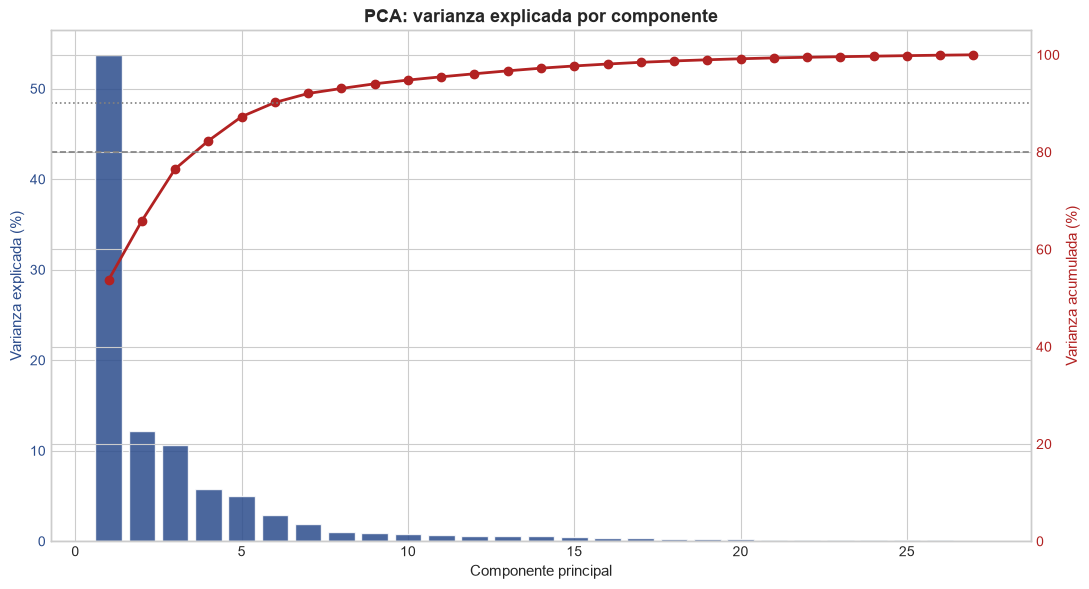

In [4]:
# Gráfico de sedimentación (scree plot) + varianza acumulada
plt.style.use("seaborn-v0_8-whitegrid")
fig, ax1 = plt.subplots(figsize=(11, 6))
componentes = np.arange(1, len(var_exp) + 1)

ax1.bar(componentes, var_exp * 100, color="#2b4c8c", alpha=0.85, edgecolor="white", label="Varianza individual")
ax1.set_xlabel("Componente principal", fontsize=11)
ax1.set_ylabel("Varianza explicada (%)", fontsize=11, color="#2b4c8c")
ax1.tick_params(axis="y", labelcolor="#2b4c8c")

ax2 = ax1.twinx()
ax2.plot(componentes, var_acum * 100, color="firebrick", marker="o", linewidth=2, label="Varianza acumulada")
ax2.axhline(80, color="gray", linestyle="--", linewidth=1.2)
ax2.axhline(90, color="gray", linestyle=":", linewidth=1.2)
ax2.set_ylabel("Varianza acumulada (%)", fontsize=11, color="firebrick")
ax2.tick_params(axis="y", labelcolor="firebrick")
ax2.set_ylim(0, 105)

ax1.set_title("PCA: varianza explicada por componente", fontsize=13, fontweight="bold")
fig.tight_layout()
plt.show()

In [5]:
# ¿Qué representa cada uno de los primeros componentes? Miramos sus cargas (loadings)
cargas = pd.DataFrame(
    pca.components_.T,
    index=X.columns,
    columns=[f"PC{i+1}" for i in range(pca.n_components_)],
)

for pc in ["PC1", "PC2", "PC3"]:
    print(f"===== {pc}: variables con mayor peso =====")
    print(cargas[pc].sort_values(key=np.abs, ascending=False).head(6).round(3))
    print()

===== PC1: variables con mayor peso =====
skill_ball_control         0.251
skill_dribbling            0.248
attacking_short_passing    0.238
attacking_crossing         0.231
goalkeeping_diving        -0.229
goalkeeping_handling      -0.229
Name: PC1, dtype: float64

===== PC2: variables con mayor peso =====
overall               0.471
movement_reactions    0.441
age                   0.313
weight_kg             0.282
potential             0.260
height_cm             0.234
Name: PC2, dtype: float64

===== PC3: variables con mayor peso =====
defending_sliding_tackle      0.390
defending_standing_tackle     0.384
attacking_heading_accuracy    0.280
height_cm                     0.243
movement_agility             -0.241
movement_balance             -0.217
Name: PC3, dtype: float64



<b>Explicación</b>: El resultado es notablemente limpio. El **primer componente por sí solo explica casi el 54%** de toda la variabilidad, y con solo **4 componentes ya cubrimos el 82%**; con 6, el 90%. Dicho de otro modo: 27 variables se pueden resumir en 4–6 dimensiones sin perder prácticamente nada. El "codo" del gráfico de sedimentación aparece justo después del tercer o cuarto componente, marcando dónde empieza a haber rendimientos decrecientes.

Y lo mejor es que esas dimensiones tienen **lectura futbolística clara**, según sus cargas:

- **PC1 (54%) — Jugador de campo vs. portero.** Carga positivo en habilidades técnicas (control de balón, regate, pase, centros) y negativo en los atributos de portero. Es, literalmente, el eje que separa a un futbolista de campo de un arquero. Que sea el componente dominante confirma que la mayor fuente de variación en el dataset es simplemente *qué tipo de jugador es cada uno*.
- **PC2 (12%) — Calidad y veteranía.** Encabezado por `overall`, `movement_reactions`, `age` y `potential`. Resume el nivel y la madurez del jugador; es el componente que más nos interesa, porque es justo la clase de información que en la inferencia asociamos al sueldo.
- **PC3 (11%) — Perfil defensivo/físico.** Carga en entradas, juego aéreo y estatura frente a agilidad/equilibrio: distingue al central corpulento del jugador ágil y ligero.

#### <b><i>Conclusión</i></b>
El PCA confirma de forma cuantitativa lo que la matriz de correlación insinuaba: la información de las 27 variables es enormemente **comprimible**. Cuatro componentes bastan para retener el 82% de la varianza, y cada uno tiene un significado futbolístico interpretable (tipo de jugador, calidad/veteranía, perfil físico-defensivo). Esto no solo valida que las variables vienen "en paquetes", sino que nos da un mapa de esos paquetes. La decisión de si usar directamente estos componentes en el modelo o simplemente apoyarnos en ellos para seleccionar variables la tomaremos tras identificar formalmente los grupos, en la siguiente sección.

#### <b><i>3. Agrupamiento de variables: los "paquetes" de habilidades</i></b>
El PCA nos dio ejes de variación, pero mezcla variables en cada componente. Ahora queremos algo más directo y visual: agrupar las variables en familias según lo parecido de su comportamiento. Para ello aplicamos un **agrupamiento jerárquico** sobre las variables, usando como medida de distancia `1 − correlación`. Así, dos variables que se mueven juntas quedan "cerca", y dos que se mueven en sentido opuesto (como un atributo de campo y uno de portero) quedan "lejos".

Es importante usar la correlación con signo y **no** su valor absoluto: queremos que los perfiles opuestos —jugador de campo frente a portero— se separen, no que se junten por el solo hecho de estar fuertemente relacionados.

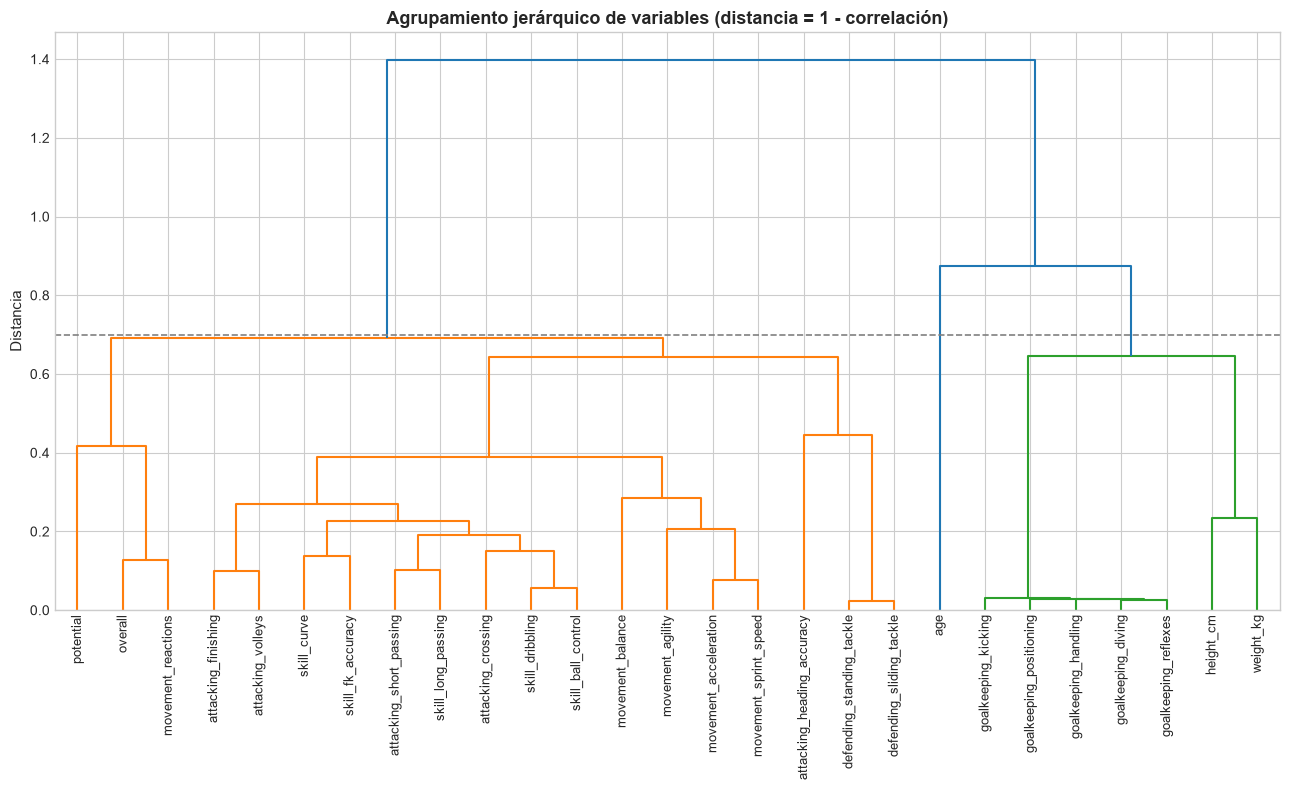

In [6]:
from scipy.cluster.hierarchy import linkage, fcluster, dendrogram
from scipy.spatial.distance import squareform

# Distancia entre variables: 1 - correlación (con signo)
dist = (1 - corr).values.copy()
np.fill_diagonal(dist, 0)
enlace = linkage(squareform(dist, checks=False), method="average")

# Dendrograma de variables
plt.style.use("seaborn-v0_8-whitegrid")
fig, ax = plt.subplots(figsize=(13, 8))
dendrogram(enlace, labels=corr.columns.tolist(), leaf_rotation=90, leaf_font_size=9,
           color_threshold=0.7, ax=ax)
ax.set_title("Agrupamiento jerárquico de variables (distancia = 1 - correlación)", fontsize=13, fontweight="bold")
ax.set_ylabel("Distancia", fontsize=11)
ax.axhline(0.7, color="gray", linestyle="--", linewidth=1.2)
plt.tight_layout()
plt.show()

In [7]:
# Cortamos el árbol en 6 grupos y los etiquetamos
n_grupos = 6
etiquetas = fcluster(enlace, n_grupos, criterion="maxclust")

grupos = {}
for var, g in zip(corr.columns, etiquetas):
    grupos.setdefault(int(g), []).append(var)

nombres = {}
for g, variables in sorted(grupos.items()):
    print(f"----- Grupo {g} ({len(variables)} variables) -----")
    for v in variables:
        print(f"   {v}")
    print()

----- Grupo 1 (3 variables) -----
   overall
   potential
   movement_reactions

----- Grupo 2 (13 variables) -----
   attacking_crossing
   attacking_finishing
   attacking_short_passing
   attacking_volleys
   skill_dribbling
   skill_curve
   skill_fk_accuracy
   skill_long_passing
   skill_ball_control
   movement_acceleration
   movement_sprint_speed
   movement_agility
   movement_balance

----- Grupo 3 (3 variables) -----
   attacking_heading_accuracy
   defending_standing_tackle
   defending_sliding_tackle

----- Grupo 4 (5 variables) -----
   goalkeeping_diving
   goalkeeping_handling
   goalkeeping_kicking
   goalkeeping_positioning
   goalkeeping_reflexes

----- Grupo 5 (2 variables) -----
   height_cm
   weight_kg

----- Grupo 6 (1 variables) -----
   age



<b>Explicación</b>: El dendrograma dibuja con nitidez las familias de habilidades, y al cortar el árbol en seis grupos obtenemos una taxonomía que cualquier entrenador reconocería:

- **Grupo de calidad/veteranía**: `overall`, `potential` y `movement_reactions`. Son los indicadores de nivel global, que se separan del resto en su propia rama — coherente con que resuman "qué tan bueno es" el jugador más que "qué sabe hacer".
- **Grupo técnico-ofensivo**: el gran bloque de atributos de ataque, regate, pases, efecto y movimiento con balón. Es el "kit" del futbolista ofensivo de campo.
- **Grupo aéreo/defensivo**: precisión de cabeza y las dos entradas (de pie y deslizante). El perfil del defensor.
- **Grupo de portería**: los cinco `goalkeeping_*`, agrupados en su propia rama bien apartada de todo lo demás, como era de esperar.
- **Grupo físico**: `height_cm` y `weight_kg`, la constitución corporal.
- **Grupo edad**: `age` queda casi solo, señal de que la edad aporta una información distinta a la de las habilidades.

Que estas familias emerjan solas, sin que nosotros le dijéramos al algoritmo qué es un portero o un delantero, es la mejor validación de que la estructura es real y no un capricho de los datos.

#### <b><i>Conclusión</i></b>
El agrupamiento jerárquico confirma y ordena todo lo anterior: las 27 variables se organizan en **seis familias coherentes** —calidad/veteranía, técnica ofensiva, juego aéreo/defensa, portería, físico y edad—. Este mapa es exactamente lo que necesitábamos: nos dice qué variables son intercambiables (dentro de un mismo grupo) y cuáles aportan información única (grupos pequeños o aislados como `age`). Con esta taxonomía en mano, la selección de features deja de ser adivinanza y pasa a ser una decisión informada, que abordamos a continuación.

#### <b><i>4. De los grupos a la selección de features</i></b>
Todo el análisis multivariante apuntaba a un destino práctico: decidir con qué variables alimentar el modelo. Ahora que conocemos la estructura de redundancias y las seis familias de habilidades, podemos convertir esos hallazgos en criterios concretos para la Fase 6.

**Qué aprendimos y qué haremos con ello:**

1. **La redundancia dentro de cada familia es enorme, así que no todas las variables aportan.** Dentro del grupo de portería, por ejemplo, los cinco atributos correlacionan por encima de 0.96: mantener los cinco es cargar al modelo con cuatro columnas casi idénticas. Lo mismo ocurre, en menor grado, con las dos variables defensivas o con regate/control de balón. **Criterio:** en modelos sensibles a la multicolinealidad (los lineales), conviene representar cada familia por uno o pocos indicadores —o directamente por un componente/índice resumen— en lugar de volcar todas las columnas.

2. **Las variables de la familia "calidad/veteranía" son las de mayor valor.** `overall`, `potential` y `movement_reactions` forman su propia rama y son, además, las que la inferencia y el EDA señalaron como más ligadas al sueldo. **Criterio:** son features de conservación obligatoria; son el corazón informativo del modelo.

3. **La edad aporta información única.** Al quedar prácticamente aislada en el dendrograma, `age` no es redundante con ninguna habilidad. **Criterio:** conservarla; podría capturar el efecto "curva de carrera" que ninguna otra variable recoge.

4. **Los atributos de portero son un caso especial.** Fuertemente correlacionados entre sí y casi sin relación con el sueldo del conjunto (lo vimos en el EDA). **Criterio:** no descartarlos sin más —sí distinguen al portero del jugador de campo—, pero tratarlos como bloque, posiblemente resumidos en un único índice de portería, para no inflar la dimensionalidad con cinco columnas de bajo aporte individual.

5. **Los árboles y el boosting toleran la redundancia mejor que los modelos lineales.** Esto matiza todo lo anterior: si el modelo final es de tipo árbol (algo que la no linealidad del sueldo hace probable), la multicolinealidad deja de ser un problema grave y podemos ser más permisivos con el número de variables. **Criterio:** ajustar la agresividad de la reducción de features según la familia de modelo que se elija.

### <b>CIERRE DEL ANÁLISIS MULTIVARIANTE</b>
El análisis multivariante nos dejó algo más valioso que un puñado de gráficos: un **mapa de la estructura interna del dataset**. Sabemos que la información de 27 variables se comprime en 4–6 dimensiones, que esas dimensiones tienen sentido futbolístico, y que las variables se organizan en seis familias con niveles de redundancia muy distintos. Con este mapa, la preparación del dataset y la ingeniería de features de la siguiente fase dejan de ser un ejercicio a ciegas: sabemos qué conservar, qué resumir y qué tratar con cuidado. Ese es exactamente el punto de partida de la Fase de Feature Engineering.